In [9]:
import os
import cv2
import numpy as np
import pyfeats
import joblib
import matplotlib.pyplot as plt

# Load komponen
model = joblib.load("model_svm.pkl")
scaler = joblib.load("scaler.pkl")
mask = joblib.load("best_mask_kombinasi.pkl")

# Preprocessing
def preprocess_image(img_path, size=(224, 224)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal membaca gambar dari {img_path}")
    img = cv2.resize(img, size)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return img

# Ekstraksi FOS
def extract_fos(img):
    mask_img = np.ones_like(img)
    fos_feats, _ = pyfeats.fos(img, mask_img)
    return np.array(fos_feats[:10])

# Ekstraksi GLCM
def extract_glcm(img):
    glcm_feats = pyfeats.glcm_features(img)
    mean_feats = glcm_feats[0]
    range_feats = glcm_feats[1]
    combined = np.concatenate([mean_feats, range_feats])
    drop_indices = [12, 13, 14, 20, 26, 27, 28]  # total 7 fitur dibuang
    keep_indices = [i for i in range(len(combined)) if i not in drop_indices]
    return combined[keep_indices]  # hasil: 22 fitur

# Gabungkan fitur (10 + 22 = 32)
def extract_combined_features(img_path):
    img = preprocess_image(img_path)
    fos = extract_fos(img)
    glcm = extract_glcm(img)
    combined = np.concatenate([fos, glcm])
    assert combined.shape[0] == 32, f"❌ Jumlah fitur = {combined.shape[0]}, harus 32"
    return combined.reshape(1, -1), img

# Prediksi batch dengan jumlah yang bisa diatur
def predict_images_in_folder(folder_path, max_images=None):
    class_labels = ['Normal', 'Tuberculosis', 'Pneumonia', 'Covid19']
    supported_ext = (".jpg", ".jpeg", ".png")

    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(supported_ext)]
    image_files = sorted(image_files)  # supaya urut
    if max_images is not None:
        image_files = image_files[:max_images]

    for filename in image_files:
        img_path = os.path.join(folder_path, filename)
        try:
            features, img = extract_combined_features(img_path)
            features_filtered = features[:, mask]
            features_scaled = scaler.transform(features_filtered)
            prediction = model.predict(features_scaled)
            label = class_labels[prediction[0]]

            print(f"🖼️ {filename} → Prediksi: {label}")

            plt.imshow(img, cmap='gray')
            plt.title(f"{filename}\nHasil Prediksi: {label}")
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"❌ Error di {filename}: {e}")

# Contoh pemanggilan
if __name__ == "__main__":
    folder_path = "C:/SKRIPSI/DataTest/TEST"  # Ganti sesuai folder
    predict_images_in_folder(folder_path, max_images=10)  # Ganti 5 sesuai jumlah gambar yang diinginkan


In [ ]:
import os
import cv2
import numpy as np
import pyfeats
import joblib
from collections import Counter

# ======== Load model dan komponen fitur ========
model = joblib.load("model_svm.pkl")
scaler = joblib.load("scaler.pkl")
mask = joblib.load("best_mask_kombinasi.pkl")  # untuk FOS+GLCM

# ======== Nama kelas sesuai training ========
class_labels = ['Normal', 'Tuberculosis', 'Pneumonia', 'Covid19'] # ubah jika multi-kelas

# ======== Preprocessing ========
def preprocess_image(img_path, size=(224, 224)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal membaca gambar dari {img_path}")
    img = cv2.resize(img, size)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return img

# ======== Ekstraksi FOS ========
def extract_fos(img):
    mask_img = np.ones_like(img)
    fos_feats, _ = pyfeats.fos(img, mask_img)
    return np.array(fos_feats[:10])

# ======== Ekstraksi GLCM ========
def extract_glcm(img):
    glcm_feats = pyfeats.glcm_features(img)
    combined = np.concatenate([glcm_feats[0], glcm_feats[1]])
    drop_indices = [12, 13, 14, 20, 26, 27, 28]
    keep_indices = [i for i in range(len(combined)) if i not in drop_indices]
    return combined[keep_indices]

# ======== Gabungkan FOS + GLCM ========
def extract_combined_features(img):
    fos = extract_fos(img)
    glcm = extract_glcm(img)
    combined = np.concatenate([fos, glcm])
    assert combined.shape[0] == 32, f"❌ Fitur gabungan tidak lengkap: {combined.shape[0]}"
    return combined.reshape(1, -1)

# ======== Rekap prediksi satu folder ========
def summarize_folder(folder_path):
    supported_ext = (".jpg", ".jpeg", ".png")
    image_files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(supported_ext)])
    predictions = []

    for filename in image_files:
        try:
            img_path = os.path.join(folder_path, filename)
            img = preprocess_image(img_path)
            feats = extract_combined_features(img)
            feats_filtered = feats[:, mask]
            feats_scaled = scaler.transform(feats_filtered)
            pred = model.predict(feats_scaled)[0]
            predictions.append(pred)
        except Exception as e:
            print(f"❌ Error di {filename}: {e}")

    # Output rekap
    counter = Counter(predictions)
    print(f"\n📁 Folder: {os.path.basename(folder_path)}")
    print("📊 Rekap Prediksi:")
    for i, label in enumerate(class_labels):
        print(f"- {label.ljust(13)}: {counter.get(i, 0)} gambar")

    if len(counter) == 1:
        only_class = class_labels[predictions[0]]
        print(f"✅ Semua gambar diprediksi sebagai: {only_class}")
    else:
        print("❌ Gambar diklasifikasikan ke lebih dari satu kelas.")

# ======== Eksekusi utama ========
if __name__ == "__main__":
    folder1 = "C:/SKRIPSI/Dataset/NORMAL"         
    folder2 = "C:/SKRIPSI/Dataset/TUBERCULOSIS"   
    folder3 = "C:/SKRIPSI/Dataset/PNEUMONIA" 
    folder4 = "C:/SKRIPSI/Dataset/COVID19" 
    
    summarize_folder(folder1)
    summarize_folder(folder2)
    summarize_folder(folder3)
    summarize_folder(folder4)



📁 Folder: NORMAL
📊 Rekap Prediksi:
- Normal       : 1 gambar
- Tuberculosis : 1 gambar
- Pneumonia    : 0 gambar
- Covid19      : 3 gambar
❌ Gambar diklasifikasikan ke lebih dari satu kelas.


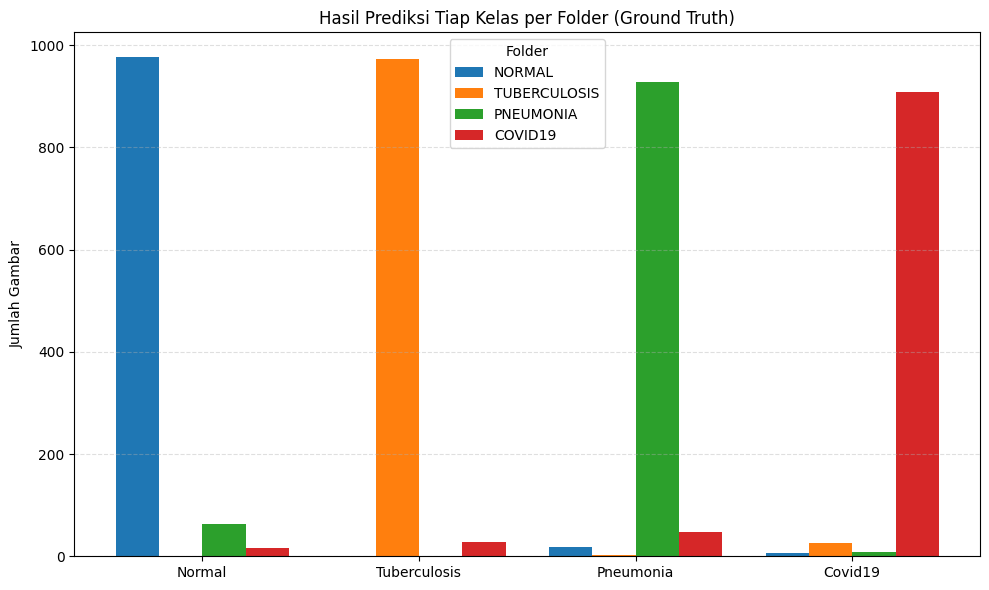

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ======== Data Rekap dari Terminal Output ========
folders = ['NORMAL', 'TUBERCULOSIS', 'PNEUMONIA', 'COVID19']
class_labels = ['Normal', 'Tuberculosis', 'Pneumonia', 'Covid19']

# Format: [Normal, TBC, Pneumonia, Covid] per folder
rekap_data = {
    'NORMAL':        [976, 0, 18, 6],
    'TUBERCULOSIS':  [0, 973, 2, 25],
    'PNEUMONIA':     [64, 0, 928, 8],
    'COVID19':       [16, 28, 47, 909]
}

# ======== Plot ========
bar_width = 0.2
x = np.arange(len(class_labels))
plt.figure(figsize=(10, 6))

for i, folder in enumerate(folders):
    plt.bar(x + i * bar_width,
            rekap_data[folder],
            width=bar_width,
            label=folder)

# Labeling
plt.xticks(x + bar_width * 1.5, class_labels)
plt.ylabel("Jumlah Gambar")
plt.title("Hasil Prediksi Tiap Kelas per Folder (Ground Truth)")
plt.legend(title="Folder")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
